In [1]:
# NBA Attendance Exploratory Data Analysis
# 3 seasons (2022-2023 to 2024-2025)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

C1 = "#1D428A"
C2 = "#C8102E"
C3 = "#FDB927"
NEUTRAL = "#8C8C8C"

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#F9F9F9",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#E5E5E5",
    "grid.linewidth":    0.8,
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
})

print("Libraries loaded.")

Libraries loaded.


In [2]:
import os
BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.makedirs(f"{BASE}/reports", exist_ok=True)

df = pd.read_csv(f"{BASE}/data/processed/nba_features.csv", parse_dates=["game_date"])
arena = pd.read_csv(f"{BASE}/data/manual/arena_info.csv")

print(f"Games:   {len(df):,}")
print(f"Teams:   {df['team'].nunique()}")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Date range: {df['game_date'].min().date()} to {df['game_date'].max().date()}")
print(f"\nLeague avg capacity: {df['attendance_pct'].mean():.1%}")
print(f"Games below 85% capacity: {df['below_85pct'].sum():,} ({df['below_85pct'].mean():.1%})")

Games:   3,705
Teams:   30
Seasons: ['2022-23', '2023-24', '2024-25']
Date range: 2022-10-18 to 2025-04-18

League avg capacity: 97.1%
Games below 85% capacity: 289 (7.8%)


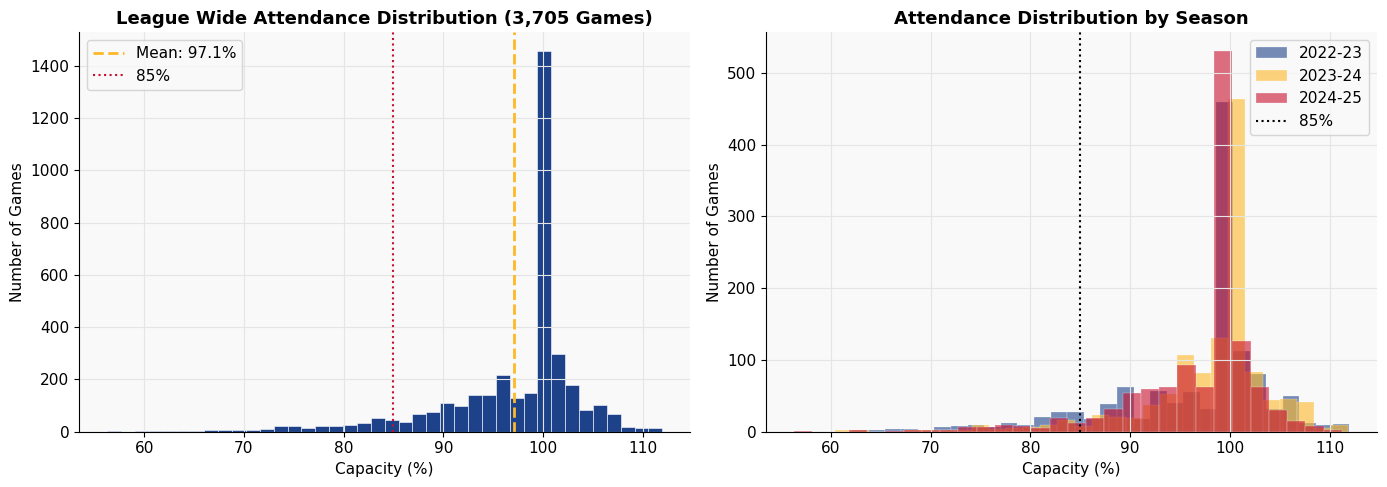

League Wide Attendance Summary
Mean:    97.1%
Median:  100.0%
Std dev: 7.2%
Min:     56.3%

Games at 100%+ capacity: 1,956 (52.8%)
Games below 85%:         289 (7.8%)


In [3]:
# Question 1: What drives game to game attendance variation within a season?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# League Wide Attendance Distribution
ax1 = axes[0]
ax1.hist(df["attendance_pct"] * 100, bins=40, color=C1, edgecolor="white", linewidth=0.4)
ax1.axvline(df["attendance_pct"].mean() * 100, color=C3, linewidth=2,
            linestyle="--", label=f"Mean: {df['attendance_pct'].mean():.1%}")
ax1.axvline(85, color=C2, linewidth=1.5, linestyle=":", label="85%")
ax1.set_xlabel("Capacity (%)")
ax1.set_ylabel("Number of Games")
ax1.set_title("League Wide Attendance Distribution (3,705 Games)")
ax1.legend()

# Attendance Distribution by Season
ax2 = axes[1]
season_colors = {"2022-23": C1, "2023-24": C3, "2024-25": C2}
for season, grp in df.groupby("season"):
    ax2.hist(grp["attendance_pct"] * 100, bins=30, alpha=0.6,
             color=season_colors[season], edgecolor="white",
             linewidth=0.3, label=season)
ax2.axvline(85, color="black", linewidth=1.5, linestyle=":", label="85%")
ax2.set_xlabel("Capacity (%)")
ax2.set_ylabel("Number of Games")
ax2.set_title("Attendance Distribution by Season")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{BASE}/reports/01_attendance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("League Wide Attendance Summary")
print(f"Mean:    {df['attendance_pct'].mean():.1%}")
print(f"Median:  {df['attendance_pct'].median():.1%}")
print(f"Std dev: {df['attendance_pct'].std():.1%}")
print(f"Min:     {df['attendance_pct'].min():.1%}")
print(f"\nGames at 100%+ capacity: {(df['attendance_pct'] >= 1.0).sum():,} ({(df['attendance_pct'] >= 1.0).mean():.1%})")
print(f"Games below 85%:         {(df['attendance_pct'] < 0.85).sum():,} ({(df['attendance_pct'] < 0.85).mean():.1%})")

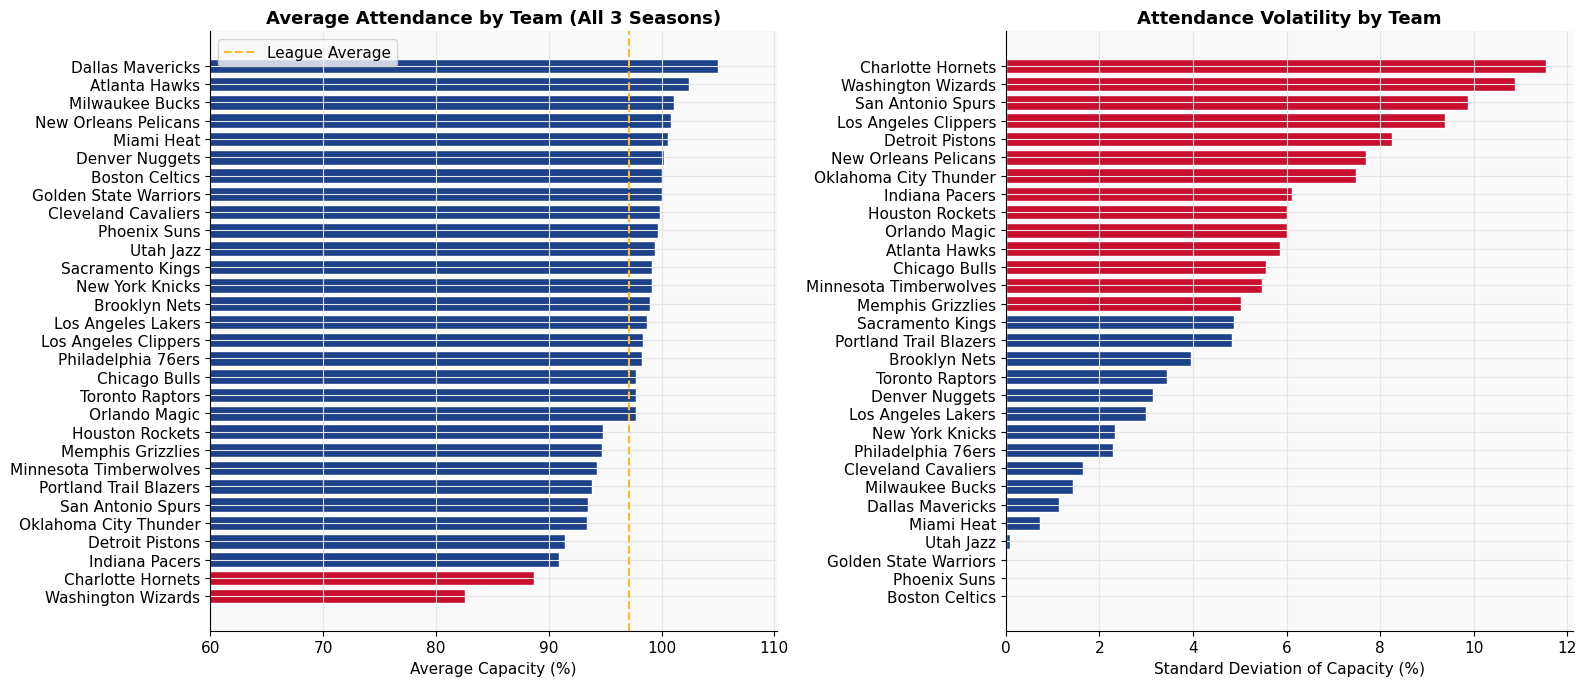

Most Volatile Teams (Highest Attendance Variation)
                team  avg_pct  std_pct  pct_below_85
   Charlotte Hornets 0.886607 0.115414          39.8
  Washington Wizards 0.825559 0.108779          63.4
   San Antonio Spurs 0.934624 0.098856          16.4
Los Angeles Clippers 0.983240 0.093870          11.4
     Detroit Pistons 0.914334 0.082606          20.5

Most Consistent Teams (Lowest Attendance Variation)
                 team  avg_pct  std_pct  pct_below_85
       Boston Celtics 1.000000 0.000000           0.0
Golden State Warriors 1.000000 0.000000           0.0
         Phoenix Suns 0.996800 0.000000           0.0
            Utah Jazz 0.993929 0.000806           0.0
           Miami Heat 1.005919 0.007279           0.0


In [4]:
# Team Level Attendance Summary
team_summary = (df.groupby("team")
    .agg(
        avg_pct   = ("attendance_pct", "mean"),
        std_pct   = ("attendance_pct", "std"),
        min_pct   = ("attendance_pct", "min"),
        games_below_85 = ("below_85pct", "sum"),
        total_games    = ("game_id", "count"),
    )
    .reset_index()
    .sort_values("avg_pct", ascending=False))

team_summary["pct_below_85"] = (team_summary["games_below_85"] /
                                 team_summary["total_games"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: avg capacity pct by team
colors = [C2 if v < 0.90 else C1 for v in team_summary["avg_pct"]]
bars = axes[0].barh(team_summary["team"], team_summary["avg_pct"] * 100,
                    color=colors, edgecolor="white")
axes[0].axvline(df["attendance_pct"].mean() * 100, color=C3, linewidth=1.5,
                linestyle="--", label="League Average")
axes[0].set_xlabel("Average Capacity (%)")
axes[0].set_title("Average Attendance by Team (All 3 Seasons)")
axes[0].set_xlim(left=60)
axes[0].invert_yaxis()
axes[0].legend()

# Right: volatility (std dev) — most and least consistent
team_summary_vol = team_summary.sort_values("std_pct", ascending=False)
colors_vol = [C2 if v > 0.05 else C1 for v in team_summary_vol["std_pct"]]
axes[1].barh(team_summary_vol["team"], team_summary_vol["std_pct"] * 100,
             color=colors_vol, edgecolor="white")
axes[1].set_xlabel("Standard Deviation of Capacity (%)")
axes[1].set_title("Attendance Volatility by Team")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{BASE}/reports/02_team_attendance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Most Volatile Teams (Highest Attendance Variation)")
print(team_summary.nlargest(5, "std_pct")[["team","avg_pct","std_pct","pct_below_85"]].to_string(index=False))
print("")
print("Most Consistent Teams (Lowest Attendance Variation)")
print(team_summary.nsmallest(5, "std_pct")[["team","avg_pct","std_pct","pct_below_85"]].to_string(index=False))

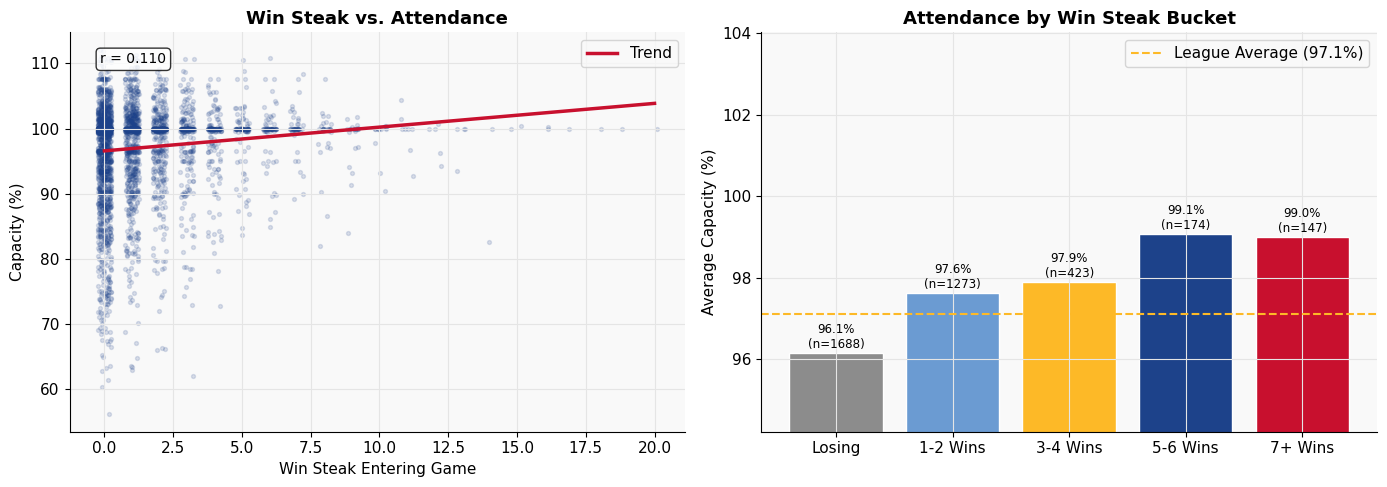

Correlation (Win Streak vs Attendance): r = 0.110

  Losing        96.1%  (-1.0pp vs avg)  n=1688
  1-2 Wins      97.6%  (+0.5pp vs avg)  n=1273
  3-4 Wins      97.9%  (+0.8pp vs avg)  n=423
  5-6 Wins      99.1%  (+2.0pp vs avg)  n=174
  7+ Wins       99.0%  (+1.9pp vs avg)  n=147


In [5]:
# Question 2: At what point during a win streak does attendance respond?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Plot with Trend Line
jitter = np.random.uniform(-0.25, 0.25, len(df))
sc = axes[0].scatter(df["win_streak"] + jitter, df["attendance_pct"] * 100,
                     alpha=0.15, s=8, color=C1)
z = np.polyfit(df["win_streak"], df["attendance_pct"] * 100, 1)
p = np.poly1d(z)
x_line = np.linspace(0, df["win_streak"].max(), 100)
axes[0].plot(x_line, p(x_line), color=C2, linewidth=2.5, label="Trend")
corr = df["win_streak"].corr(df["attendance_pct"])
axes[0].set_xlabel("Win Steak Entering Game")
axes[0].set_ylabel("Capacity (%)")
axes[0].set_title("Win Steak vs. Attendance")
axes[0].text(0.05, 0.95, f"r = {corr:.3f}", transform=axes[0].transAxes,
             fontsize=10, va="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
axes[0].legend()

# Bucketed Bar Chart
def streak_bucket(n):
    if n >= 7:   return "7+ Wins"
    elif n >= 5: return "5-6 Wins"
    elif n >= 3: return "3-4 Wins"
    elif n >= 1: return "1-2 Wins"
    else:        return "Losing"

bucket_order  = ["Losing", "1-2 Wins", "3-4 Wins", "5-6 Wins", "7+ Wins"]
bucket_colors = [NEUTRAL, "#6B9BD2", C3, C1, C2]

df["streak_bucket"] = df["win_streak"].apply(streak_bucket)
streak_agg = (df.groupby("streak_bucket")["attendance_pct"]
              .agg(["mean","count"])
              .reindex(bucket_order).reset_index())

bars = axes[1].bar(streak_agg["streak_bucket"],
                   streak_agg["mean"] * 100,
                   color=bucket_colors, edgecolor="white")
league_avg = df["attendance_pct"].mean() * 100
axes[1].axhline(league_avg, color=C3, linewidth=1.5,
                linestyle="--", label=f"League Average ({league_avg:.1f}%)")
axes[1].set_ylim(bottom=streak_agg["mean"].min() * 100 * 0.98)
axes[1].set_ylabel("Average Capacity (%)")
axes[1].set_title("Attendance by Win Steak Bucket")
axes[1].legend()

for bar, val, cnt in zip(bars, streak_agg["mean"], streak_agg["count"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{val*100:.1f}%\n(n={cnt})",
                 ha="center", va="bottom", fontsize=8.5)

plt.tight_layout()
plt.savefig(f"{BASE}/reports/03_win_streak.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Correlation (Win Streak vs Attendance): r = {corr:.3f}")
print()
for _, row in streak_agg.iterrows():
    diff = (row["mean"] - df["attendance_pct"].mean()) * 100
    flag = "  <- Before this point you may still need promotions to fill seats" if row["streak_bucket"] == "3-4 wins" else \
           "  <- Winning streak is selling tickets itself" if row["streak_bucket"] == "5-6 wins" else ""    
    print(f"  {row.streak_bucket:<12}  {row['mean']*100:.1f}%  ({diff:+.1f}pp vs avg)  n={int(row['count'])}{flag}")

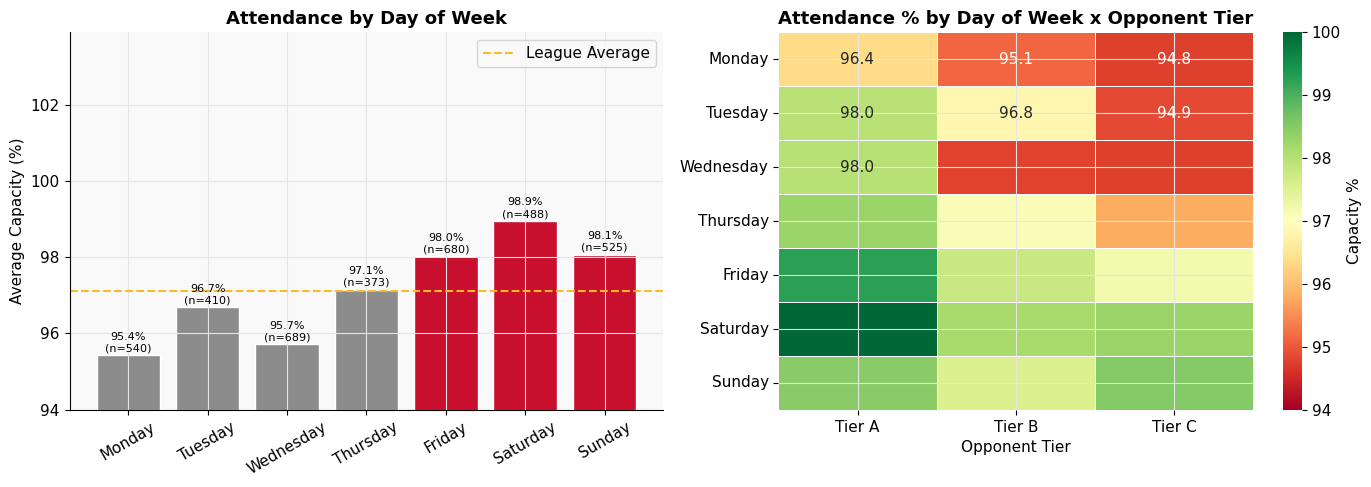

Day of Week Gap: Saturday (98.9%) vs Monday (95.4%)
Gap: 3.5%

Interaction Table (Average Capacity %):
opponent_tier      A     B     C
day_of_week                     
Monday          96.4  95.1  94.8
Tuesday         98.0  96.8  94.9
Wednesday       98.0  94.8  94.8
Thursday        98.3  97.1  95.8
Friday          99.3  97.8  97.2
Saturday       100.3  98.2  98.3
Sunday          98.5  97.5  98.5

Insight: Tier A on Monday (96.4%) vs Tier C on Saturday (98.3%)
More marketable/higher level opponents suffer a weeknight penalty. In this example, about -2.0%.


In [6]:
# Question 3: Which impacts attendance more, day of the week or opponent quality? 

DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# Day of Week Baseline
dow = (df.groupby("day_of_week")["attendance_pct"]
       .agg(["mean","count","std"])
       .reindex(DOW_ORDER).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of Week
dow_colors = [C2 if d in ["Friday","Saturday","Sunday"] else NEUTRAL
              for d in dow["day_of_week"]]
bars = axes[0].bar(dow["day_of_week"], dow["mean"] * 100,
                   color=dow_colors, edgecolor="white")
axes[0].axhline(df["attendance_pct"].mean() * 100, color=C3,
                linewidth=1.5, linestyle="--", label="League Average")
axes[0].set_ylim(bottom=dow["mean"].min() * 100 * 0.985)
axes[0].set_ylabel("Average Capacity (%)")
axes[0].set_title("Attendance by Day of Week")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend()
for bar, val, cnt in zip(bars, dow["mean"], dow["count"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{val*100:.1f}%\n(n={cnt})", ha="center", va="bottom", fontsize=8)

# Heatmap: Day of Week x Opponent Tier
pivot = df.pivot_table(
    values="attendance_pct",
    index="day_of_week",
    columns="opponent_tier",
    aggfunc="mean"
)
pivot = pivot.reindex(DOW_ORDER).reindex(columns=["A","B","C"]) * 100

sns.heatmap(pivot, ax=axes[1], annot=True, fmt=".1f",
            cmap="RdYlGn", vmin=94, vmax=100,
            linewidths=0.5, cbar_kws={"label": "Capacity %"})
axes[1].set_title("Attendance % by Day of Week x Opponent Tier")
axes[1].set_xlabel("Opponent Tier")
axes[1].set_ylabel("")
axes[1].set_xticklabels(["Tier A", "Tier B", "Tier C"])

plt.tight_layout()
plt.savefig(f"{BASE}/reports/04_dow_opponent_interaction.png", dpi=150, bbox_inches="tight")
plt.show()

# Insight
best_day  = dow.loc[dow["mean"].idxmax(), "day_of_week"]
worst_day = dow.loc[dow["mean"].idxmin(), "day_of_week"]
gap = (dow["mean"].max() - dow["mean"].min()) * 100
print(f"Day of Week Gap: {best_day} ({dow['mean'].max():.1%}) vs {worst_day} ({dow['mean'].min():.1%})")
print(f"Gap: {gap:.1f}%")
print()
print("Interaction Table (Average Capacity %):")
print(pivot.round(1).to_string())
print()
tier_a_mon = pivot.loc["Monday", "A"] if "Monday" in pivot.index else None
tier_c_sat = pivot.loc["Saturday", "C"] if "Saturday" in pivot.index else None
if tier_a_mon and tier_c_sat:
    print(f"Insight: Tier A on Monday ({tier_a_mon:.1f}%) vs Tier C on Saturday ({tier_c_sat:.1f}%)")
    print(f"More marketable/higher level opponents suffer a weeknight penalty. In this example, about {tier_a_mon - tier_c_sat:.1f}%.")

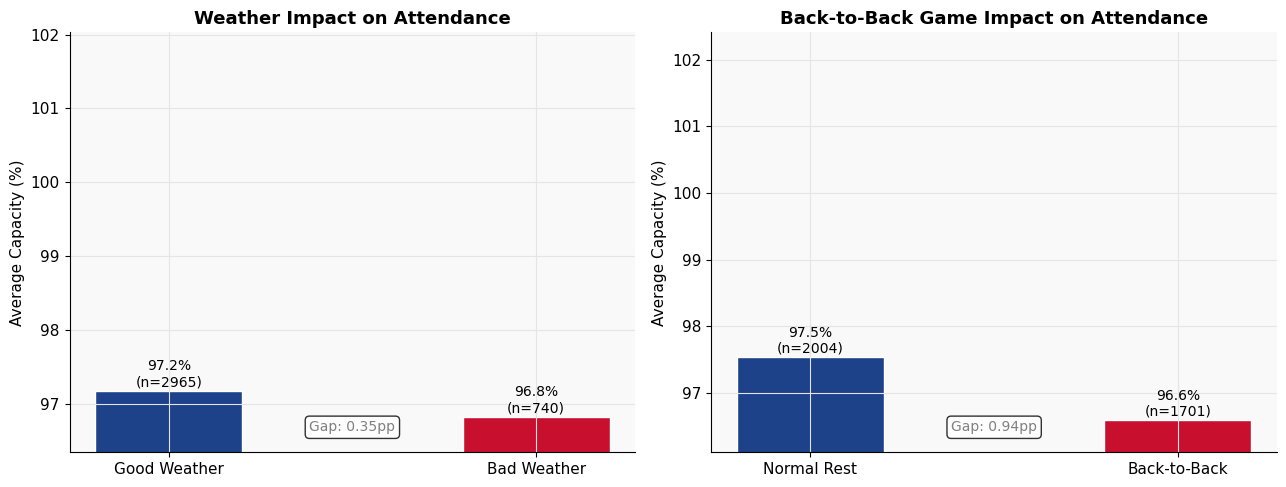

Weather Penalty:    0.35%
Back-to-Back Penalty: 0.94%


In [7]:
# Question 4: How does weather and back to back games impact attendance?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Weather
weather_agg = (df.groupby("is_bad_weather")["attendance_pct"]
               .agg(["mean","count","std"]).reset_index())
weather_labels = ["Good Weather", "Bad Weather"]
weather_colors = [C1, C2]
bars1 = axes[0].bar(weather_labels, weather_agg["mean"] * 100,
                    color=weather_colors, edgecolor="white", width=0.4)
axes[0].set_ylim(bottom=weather_agg["mean"].min() * 100 * 0.995)
axes[0].set_ylabel("Average Capacity (%)")
axes[0].set_title("Weather Impact on Attendance")
for bar, val, cnt in zip(bars1, weather_agg["mean"], weather_agg["count"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val*100:.1f}%\n(n={cnt})", ha="center", va="bottom", fontsize=10)

weather_gap = (weather_agg.loc[weather_agg["is_bad_weather"]==0,"mean"].values[0] -
               weather_agg.loc[weather_agg["is_bad_weather"]==1,"mean"].values[0]) * 100
axes[0].text(0.5, 0.05, f"Gap: {weather_gap:.2f}pp", transform=axes[0].transAxes,
             ha="center", fontsize=10, color="gray",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Back to Back
b2b_agg = (df.groupby("is_back_to_back")["attendance_pct"]
           .agg(["mean","count","std"]).reset_index())
b2b_labels = ["Normal Rest", "Back-to-Back"]
bars2 = axes[1].bar(b2b_labels, b2b_agg["mean"] * 100,
                    color=[C1, C2], edgecolor="white", width=0.4)
axes[1].set_ylim(bottom=b2b_agg["mean"].min() * 100 * 0.995)
axes[1].set_ylabel("Average Capacity (%)")
axes[1].set_title("Back-to-Back Game Impact on Attendance")
for bar, val, cnt in zip(bars2, b2b_agg["mean"], b2b_agg["count"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val*100:.1f}%\n(n={cnt})", ha="center", va="bottom", fontsize=10)

b2b_gap = (b2b_agg.loc[b2b_agg["is_back_to_back"]==0,"mean"].values[0] -
           b2b_agg.loc[b2b_agg["is_back_to_back"]==1,"mean"].values[0]) * 100
axes[1].text(0.5, 0.05, f"Gap: {b2b_gap:.2f}pp", transform=axes[1].transAxes,
             ha="center", fontsize=10, color="gray",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(f"{BASE}/reports/05_weather_b2b.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Weather Penalty:    {weather_gap:.2f}%")
print(f"Back-to-Back Penalty: {b2b_gap:.2f}%")

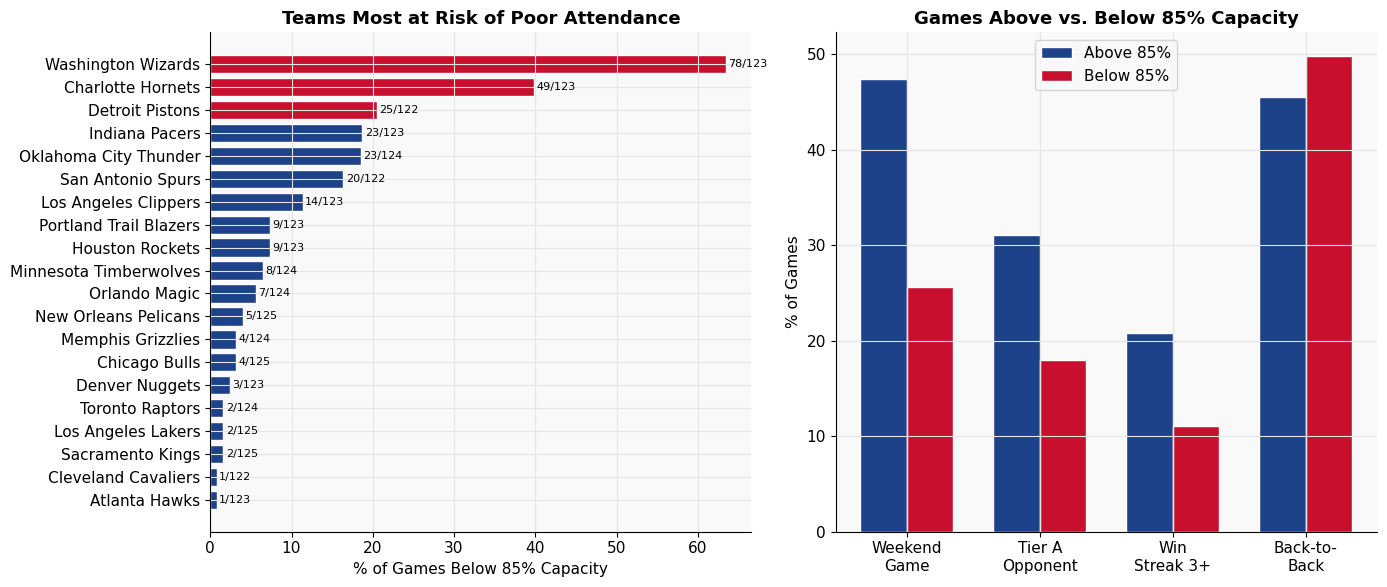

Total Games Below 85% Capacity: 289 (7.8%)

Below-85% Games vs. All games:
  Weekend Game           Below 85%: 25.6%  |  Above 85%: 47.4%
  Tier A Opponent        Below 85%: 18.0%  |  Above 85%: 31.1%
  Win Streak 3+          Below 85%: 11.1%  |  Above 85%: 20.8%
  Back-to- Back          Below 85%: 49.8%  |  Above 85%: 45.6%


In [8]:
# Question 5: Which teams and game situations are most at risk of poor attendance?

# Teams with most games below 85%
at_risk = (df.groupby("team")
           .agg(total_games=("game_id","count"),
                games_below_85=("below_85pct","sum"),
                avg_pct=("attendance_pct","mean"))
           .reset_index())
at_risk["pct_below_85"] = at_risk["games_below_85"] / at_risk["total_games"] * 100
at_risk = at_risk[at_risk["games_below_85"] > 0].sort_values("pct_below_85", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Teams by % games below 85%
colors = [C2 if p > 20 else C1 for p in at_risk["pct_below_85"]]
axes[0].barh(at_risk["team"], at_risk["pct_below_85"],
             color=colors, edgecolor="white")
axes[0].set_xlabel("% of Games Below 85% Capacity")
axes[0].set_title("Teams Most at Risk of Poor Attendance")
axes[0].invert_yaxis()
for i, (_, row) in enumerate(at_risk.iterrows()):
    axes[0].text(row.pct_below_85 + 0.3, i,
                 f"{row.games_below_85:.0f}/{row.total_games:.0f}",
                 va="center", fontsize=8)

# Below 85% Games
below_85 = df[df["below_85pct"] == 1]
above_85 = df[df["below_85pct"] == 0]

categories = ["Weekend\nGame", "Tier A\nOpponent", "Win\nStreak 3+", "Back-to-\nBack"]
below_vals = [
    below_85["is_weekend"].mean() * 100,
    (below_85["opponent_tier"] == "A").mean() * 100,
    (below_85["win_streak"] >= 3).mean() * 100,
    below_85["is_back_to_back"].mean() * 100,
]
above_vals = [
    above_85["is_weekend"].mean() * 100,
    (above_85["opponent_tier"] == "A").mean() * 100,
    (above_85["win_streak"] >= 3).mean() * 100,
    above_85["is_back_to_back"].mean() * 100,
]

x = np.arange(len(categories))
w = 0.35
axes[1].bar(x - w/2, above_vals, w, label="Above 85%", color=C1, edgecolor="white")
axes[1].bar(x + w/2, below_vals, w, label="Below 85%", color=C2, edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel("% of Games")
axes[1].set_title("Games Above vs. Below 85% Capacity")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{BASE}/reports/06_at_risk_games.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total Games Below 85% Capacity: {len(below_85):,} ({len(below_85)/len(df):.1%})")
print(f"\nBelow-85% Games vs. All games:")
for cat, bv, av in zip(categories, below_vals, above_vals):
    cat_clean = cat.replace("\n", " ")
    print(f"  {cat_clean:<22} Below 85%: {bv:.1f}%  |  Above 85%: {av:.1f}%")